## XAI: Model-agnostic methods


# Bike Rental Dataset


In [1]:
install.packages('randomForest')
install.packages('pdp')
install.packages('ggplot2')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(randomForest)
library(pdp)
library(ggplot2)
library(dplyr)


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘ggplot2’


The following object is masked from ‘package:randomForest’:

    margin



Attaching package: ‘dplyr’


The following object is masked from ‘package:randomForest’:

    combine


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [4]:
bike_data <- read.csv("day.csv")

bike_data$dteday <- as.Date(bike_data$dteday)
bike_data$days_since_2011 <- as.numeric(bike_data$dteday - as.Date("2011-01-01"))

head(bike_data)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,days_since_2011
,<int>,<date>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>
1,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.1604460,331,654,985,0
2,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.2485390,131,670,801,1
3,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.2483090,120,1229,1349,2
4,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.1602960,108,1454,1562,3
5,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.1869000,82,1518,1600,4
6,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.0895652,88,1518,1606,5


## One dimensional Partial Dependence Plot

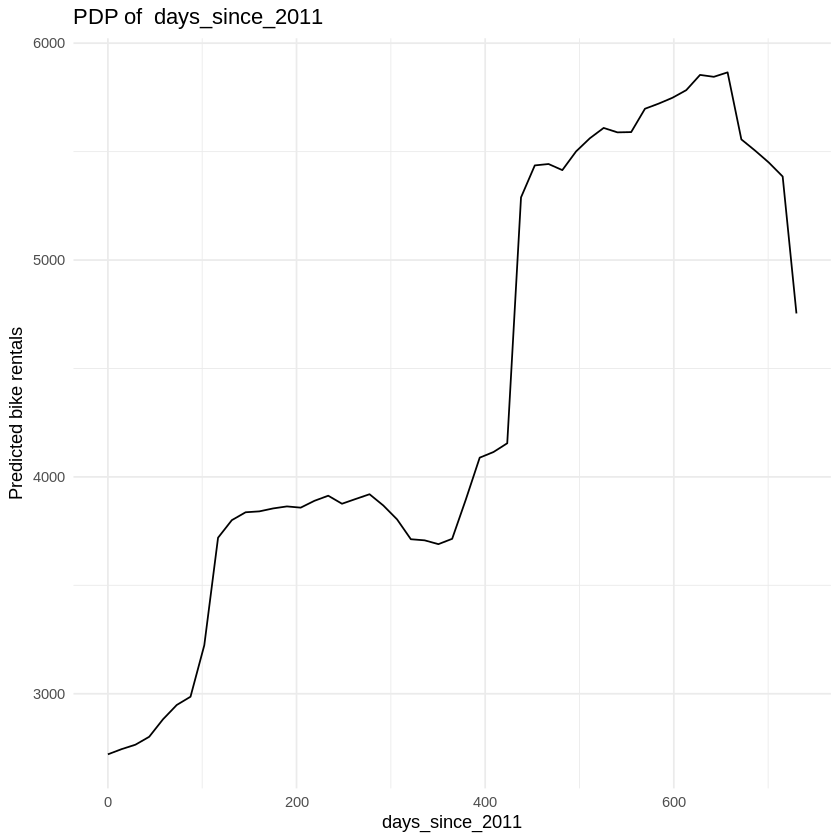

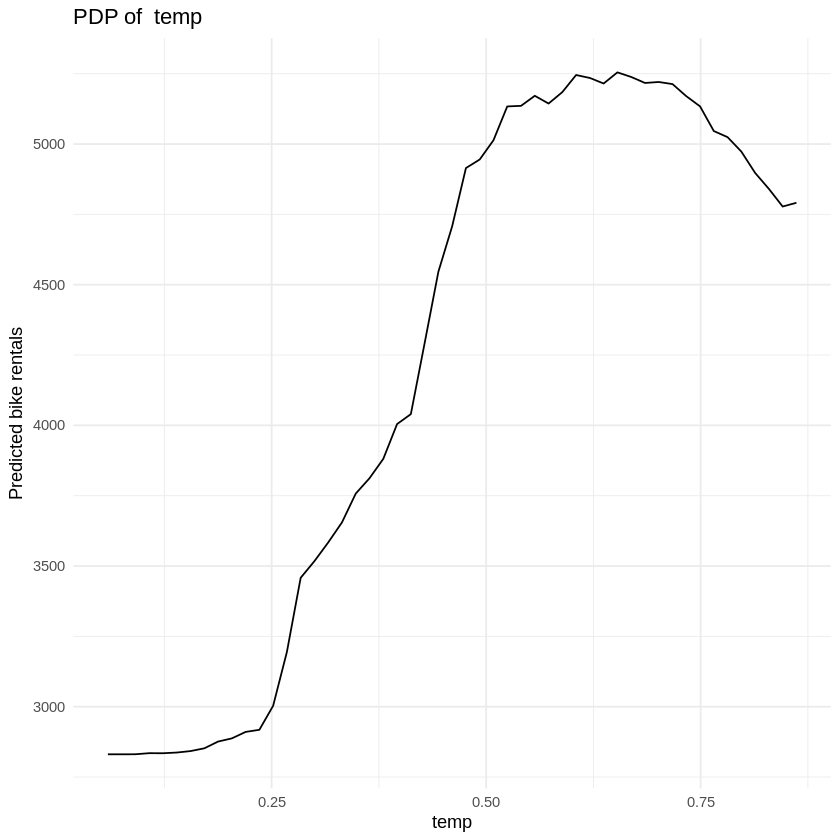

$days_since_2011

$temp

$hum

$windspeed


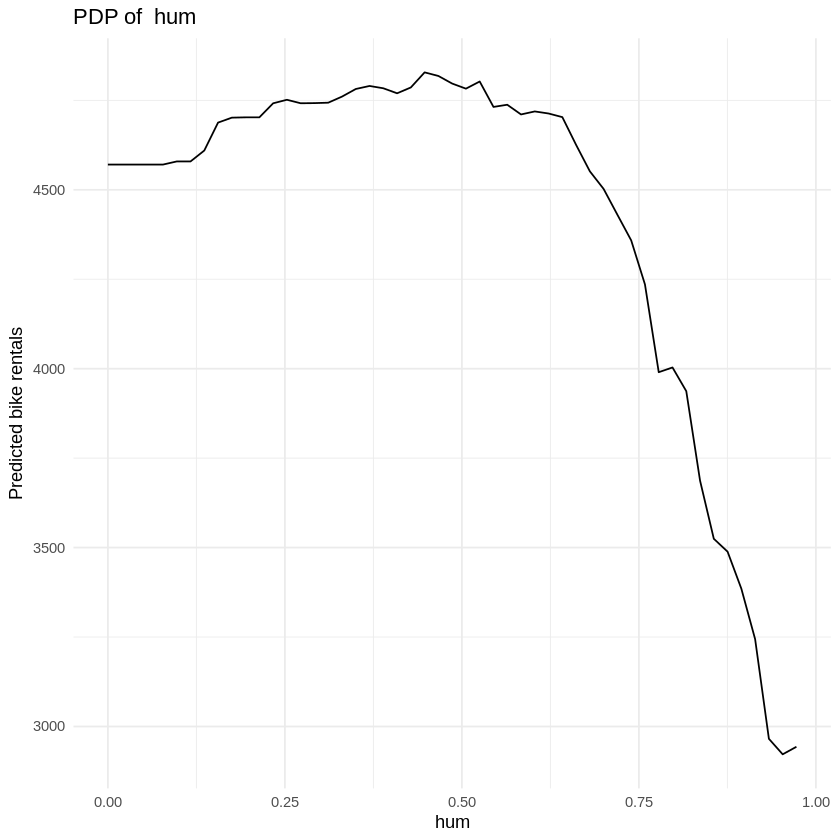

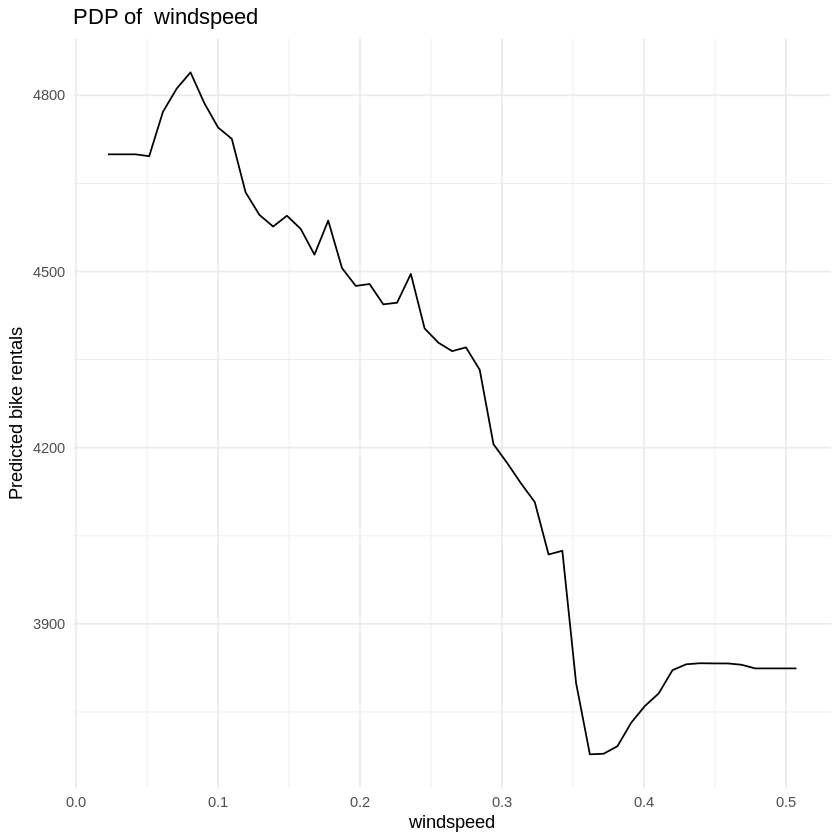

In [5]:
model_bici <- randomForest(cnt ~ days_since_2011 + temp + hum + windspeed,
                            data = bike_data, ntree = 100)
set.seed(42)

features <- c("days_since_2011", "temp", "hum", "windspeed")
pdp_graficos <- list()

for(f in features) {
  p <- partial(model_bici, pred.var = f,
   train = bike_data)
  pdp_graficos[[f]] <- autoplot(p) + theme_minimal() +
    ylab("Predicted bike rentals")+
     ggtitle(paste("PDP of ", f))
}

pdp_graficos

## Bidimensional Partial Dependency Plot.


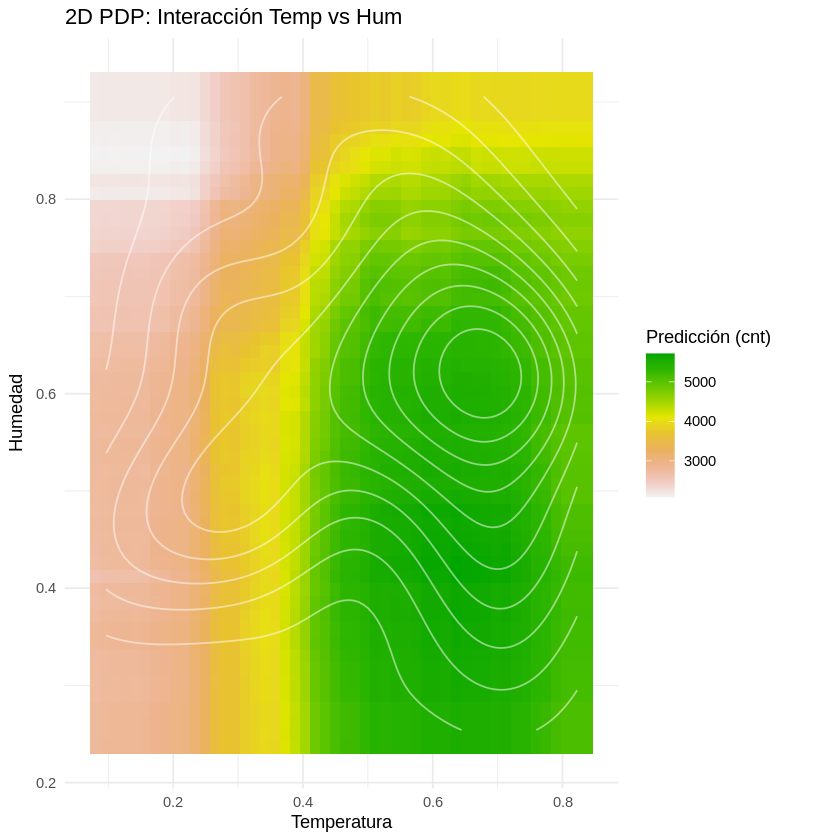

In [ ]:
# We use 50 samples as a minimum
set.seed(123)
bike_subconj <- bike_data[sample(nrow(bike_data), 50), ]

# We generate a 2D PDP for temp and hum
pdp_2d <- partial(model_bici,
                  pred.var = c("temp", "hum"),
                  train = bike_subconj)


ggplot(pdp_2d, aes(x = temp, y = hum, fill = yhat)) +
  geom_tile(width = 0.05, height = 0.05) +
  scale_fill_gradientn(colours = rev(terrain.colors(10))) +
  geom_density2d(data = bike_subconj, aes(x = temp, y = hum),
                 inherit.aes = FALSE, color = "white", alpha = 0.5) +
  theme_minimal() +
  labs(title = "2D PDP: Interaction Temp vs Hum",
       x = "Temperature",
       y = "Humidity",
       fill = "Prediction (cnt)")

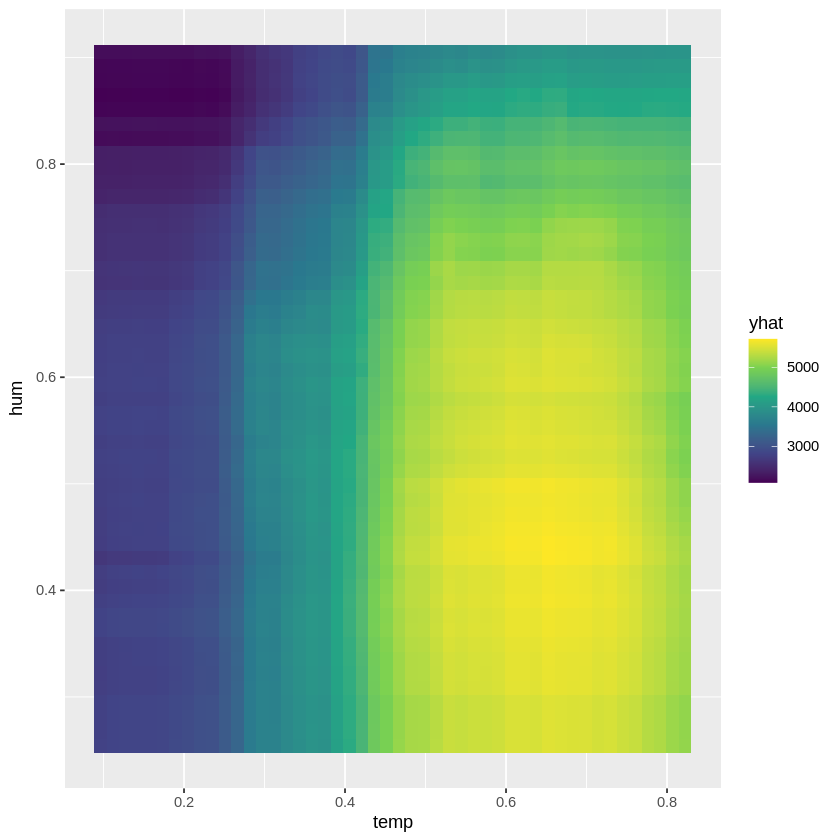

In [ ]:
autoplot(pdp_2d)

# House Price Dataset

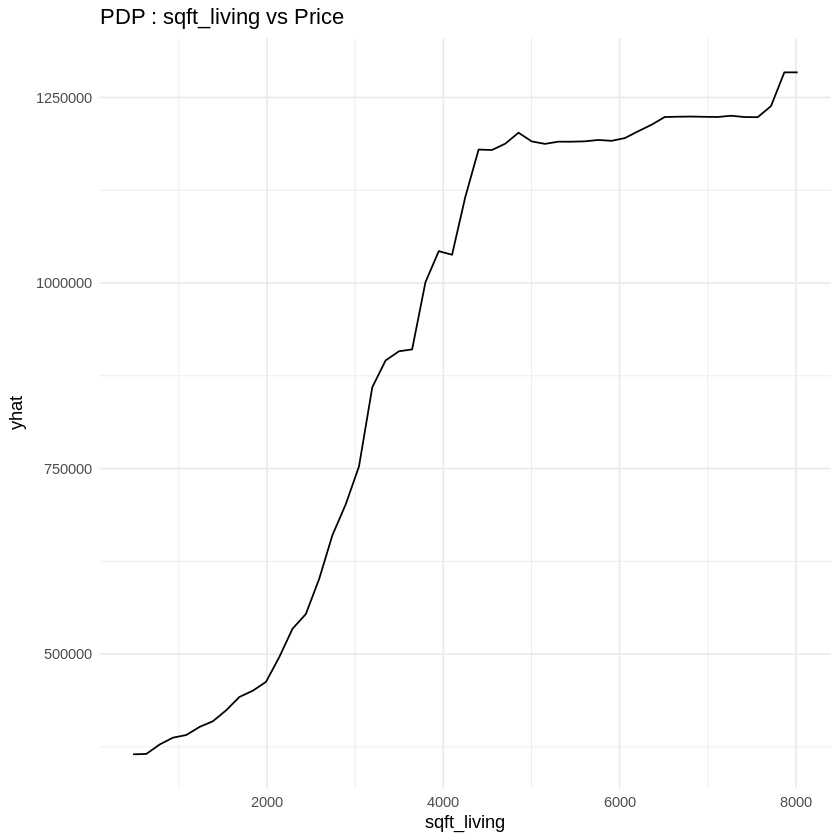

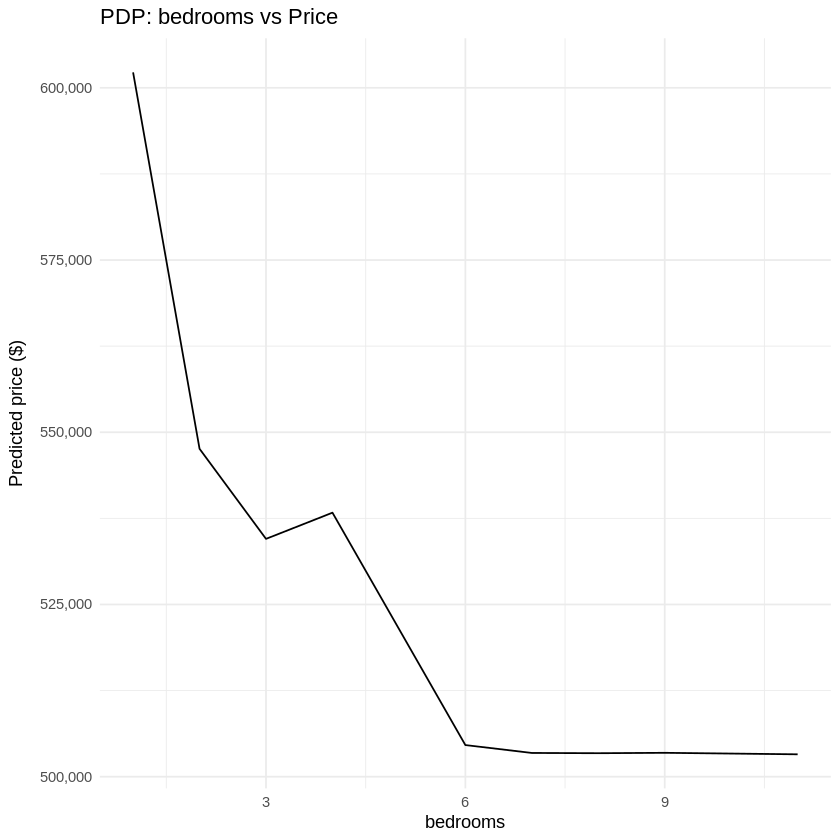

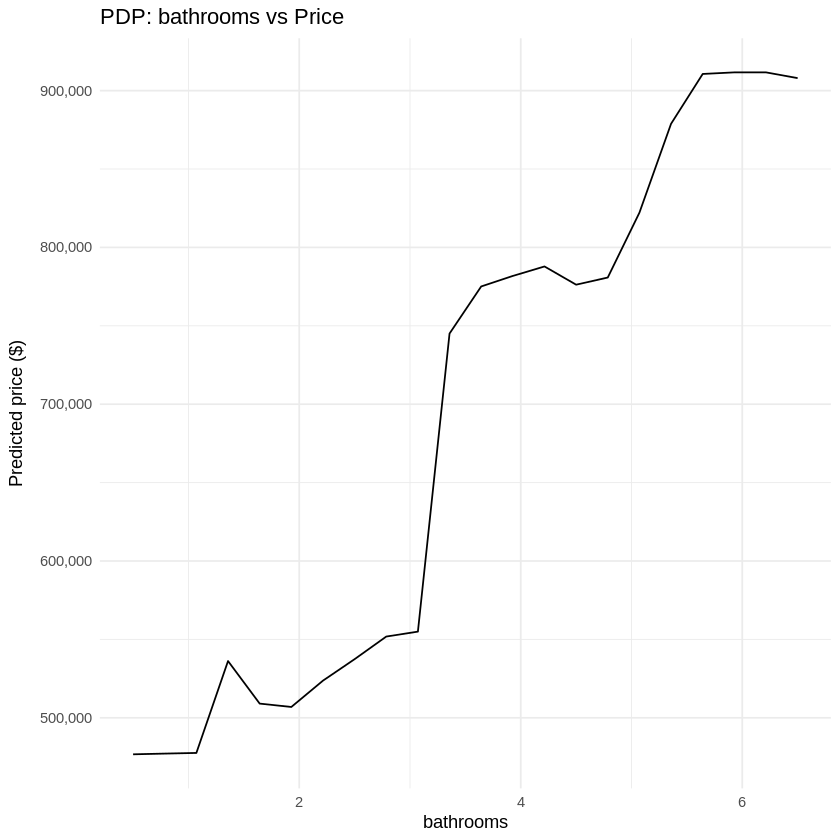

$bedrooms

$bathrooms

$sqft_living

$floors


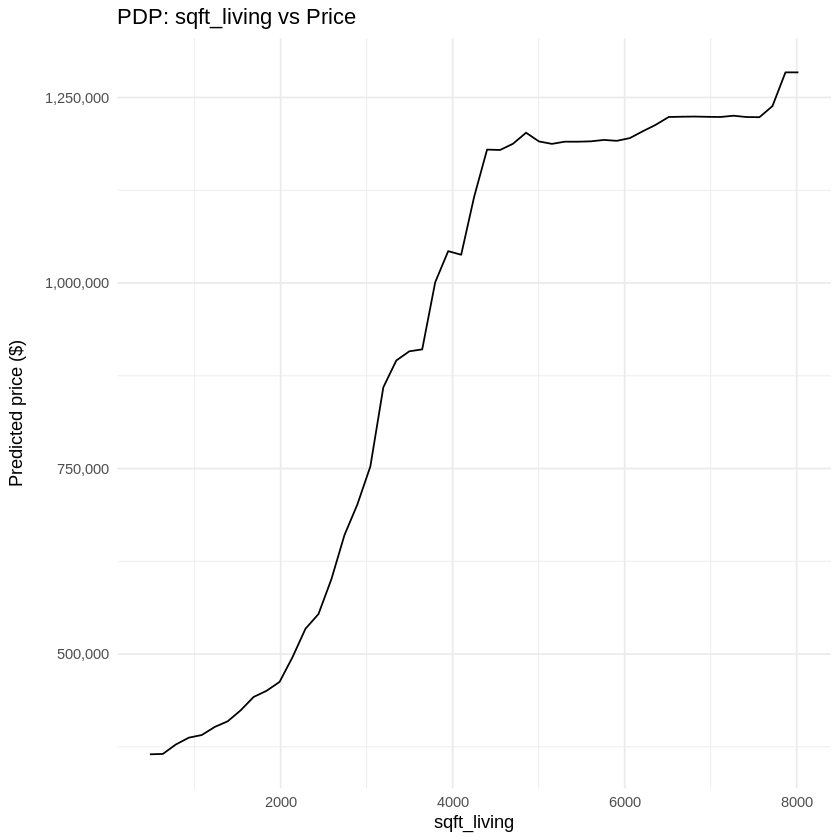

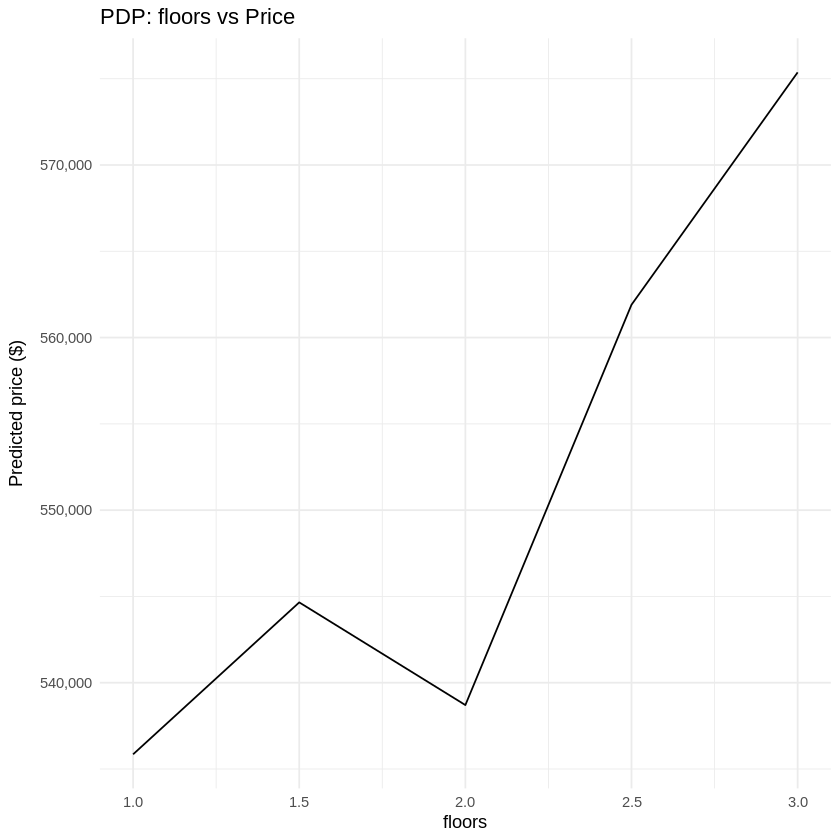

In [ ]:
house_data <- read.csv("kc_house_data.csv")

set.seed(42)

house_subconj <- house_data[sample(nrow(house_data),1500),]

model_house <- randomForest(price ~ bedrooms + bathrooms + sqft_living +sqft_lot + floors + yr_built,
                            data = house_subconj)

pd_house <- partial(model_house, pred.var = "sqft_living", train = house_subconj)

autoplot(pd_house) + theme_minimal() + ggtitle("PDP : sqft_living vs Price")


features_house <- c("bedrooms", "bathrooms", "sqft_living", "floors")
pdp_house_graficos <- list()

for (f in features_house) {
  p <- partial(model_house, pred.var = f, train = house_subconj)

  pdp_house_graficos[[f]] <- autoplot(p) +
    theme_minimal() +
    xlab(f) +
    ylab("Predicted price ($)") +
    ggtitle(paste("PDP:", f, "vs Price")) +
    scale_y_continuous(labels = scales::comma)
}

pdp_house_graficos